In [49]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from rdkit import Chem
import torch
import torch.nn as nn
from torch.utils.data import Dataset,Subset,DataLoader
from transformers import AutoTokenizer,AutoModel
from sklearn.model_selection import train_test_split

In [36]:
qm8=pd.read_csv("C:\\Users\\vasum\\Desktop\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm8.csv")
qm9=pd.read_csv("C:\\Users\\vasum\\Desktop\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm9.csv")

In [37]:
print(qm8.shape)
print(qm9.shape)

(21786, 17)
(133885, 21)


In [38]:
#checking for hidden missing values

empty_smiles = (qm9['smiles'].str.strip() == "").sum()
print(empty_smiles)

0


In [39]:
'''Canonicalizing smilies - since the smiles in both qm8 nd qm9 are
 in different format we have to change it to a standard format so that
 one molecule should not be treated as two  different molecules'''

def canonicalize(smiles):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smiles))

qm8['smiles_new'] = qm8['smiles'].apply(canonicalize)
qm9['smiles_new'] = qm9['smiles'].apply(canonicalize)

In [40]:
#full outter join to merge both the data

df = pd.merge(qm8, qm9, on='smiles_new', how='outer')

In [41]:
df.shape

(133925, 39)

In [42]:
#Removing invalid smiles

def valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

df = df[df['smiles_new'].apply(valid_smiles)]
df = df.reset_index(drop=True)

print("Dataset size:", df.shape)

Dataset size: (133925, 39)


In [43]:
#smiles_x --> qm8
#smiles_y --> qm9
#smiles_new --> canonical smiles

target_cols = df.columns.drop(['smiles_x','smiles_y','smiles_new'])

In [44]:
'''creating a mask to indicate which molecular property values are valid so that the
model only computes loss on real targets and ignores missing values'''

mask = ~df[target_cols].isna()
mask = mask.astype(int)

In [47]:
#filling NaN Values

df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
df[target_cols] = df[target_cols].fillna(0)

In [48]:
#canonical smiles string to list

smiles_list = df['smiles_new'].tolist()
targets = df[target_cols].values             #.values converts df to array
mask = mask.values

In [50]:
#for each smiles string s compute its length and storing it in a list

lengths = [len(s) for s in smiles_list]


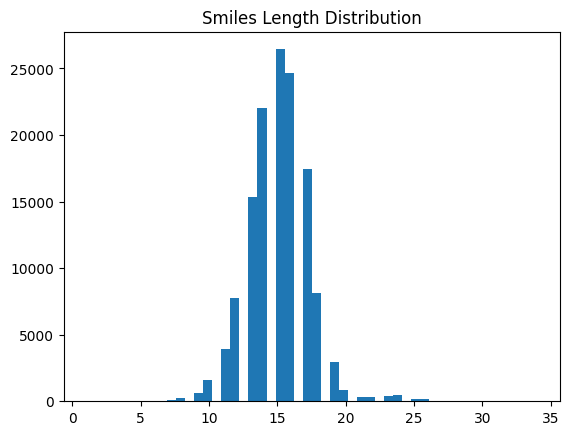

In [51]:
#this plot shows how frequently different lengths appear

plt.hist(lengths, bins=50)
plt.title("Smiles Length Distribution")
plt.show()

In [52]:
print("Max length:", max(lengths))

Max length: 34


In [17]:
'''finding maximum length to decide the maximum length for the transformer
 tokenizer as Transformer requires a fixed input length and if the length of
 smiles is greater than the maximum input in Transformer then the smiles
 would be cut (truncated)'''

'finding maximum length to decide the maximum length for the transformer\n tokenizer as Transformer requires a fixed input length and if the length of\n smiles is greater than the maximum input in Transformer then the smiles\n would be cut (truncated)'

In [54]:
'''Transformers use gradient descent,if targets have different scales model training
becomes unstable by normalizing all properties are on a similar scale which stabilizes 
training and improves model convergence'''

target_mean = targets.mean(axis=0)
target_std = targets.std(axis=0) + 1e-8
targets = (targets - target_mean) / target_std
print(targets)

[[ 4.77556558  4.2213421  10.61842698 ...  5.64198287  5.63381988
   5.705136  ]
 [ 3.88175331  3.42172376 -0.16140738 ...  5.68920521  5.68314701
   5.7354187 ]
 [ 2.85666091  2.63772365 -0.16140738 ...  4.5020112   4.49701544
   4.52999281]
 ...
 [ 1.61096895  1.97794461  4.94333731 ...  3.87017595  3.86721164
   3.91735417]
 [ 1.89426497  1.68465329  1.25656798 ...  4.11201119  4.10734376
   4.18587067]
 [ 2.13585054  2.05731638  0.14781196 ...  5.51206946  5.50483309
   5.59413455]]


In [55]:
'''Converting targets to tensors because PyTorch neural networks require
tensors as inputs to compute predictions and calculate loss during training'''

targets = torch.tensor(targets, dtype=torch.float)
mask = torch.tensor(mask, dtype=torch.float)


In [58]:
print(targets)
print(mask)

tensor([[ 4.7756,  4.2213, 10.6184,  ...,  5.6420,  5.6338,  5.7051],
        [ 3.8818,  3.4217, -0.1614,  ...,  5.6892,  5.6831,  5.7354],
        [ 2.8567,  2.6377, -0.1614,  ...,  4.5020,  4.4970,  4.5300],
        ...,
        [ 1.6110,  1.9779,  4.9433,  ...,  3.8702,  3.8672,  3.9174],
        [ 1.8943,  1.6847,  1.2566,  ...,  4.1120,  4.1073,  4.1859],
        [ 2.1359,  2.0573,  0.1478,  ...,  5.5121,  5.5048,  5.5941]])
tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [59]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

In [60]:
#coverting smiles into token IDs
'''Transformers require all sequences to have the same length so they must 
be padded to equal size (padding=True)'''

encodings = tokenizer(
    smiles_list,
    padding=True,
    truncation=True,          #smiles > max length , cut it
    max_length=64,
    return_tensors="pt"
)

print(encodings)

{'input_ids': tensor([[ 0, 39,  2,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        ...,
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


In [61]:
'''input_ids contain the numerical tokens representing smiles and 
attetion_mask tells transformer which tokens are real and which are padded'''

input_ids = encodings["input_ids"]
attention_mask = encodings["attention_mask"]    #1 --> real token
                                                #0 --> padded token
print(input_ids)
print(attention_mask)
                                             

tensor([[ 0, 39,  2,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        ...,
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1]])
tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])


In [62]:
class MoleculeDataset(Dataset):

    def __init__(self, input_ids, attention_mask, targets, mask):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.targets = targets
        self.mask = mask

    def __len__(self):                       #returns dataset size
        return len(self.targets)

    def __getitem__(self, idx):                 #returns one sample at a time
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "targets": self.targets[idx],
            "mask": self.mask[idx]
        }
    
dataset = MoleculeDataset(
    input_ids,
    attention_mask,
    targets,
    mask
)

In [ ]:
'''without dataloader model processes 1 molecule at a time and with dataloader model
 processes batch of molecules'''

In [63]:
indices = np.arange(len(dataset))    #creates an array of indices representing every molecule in the dataset

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=42
)

#Subset creates smaller datasets using selected indices
train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

'''DataLoader feeds data to the model during training in batches ,instead of processing
 the entire dataset at once, the model processes small groups of samples'''

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

In [64]:
'''PyTorch models are written as classes so that we can define model layers and forward
computation'''

'''super().__init__ calls constructor of nn.Module.It is necessary so that Pytorch can
track parameters,compute gradients and perform backpropagation'''

class ChemBERTaRegressor(nn.Module):

    def __init__(self, output_dim, dropout=0.2):       #output_dim represents no of properties to predict
        super().__init__()

        # Pretrained ChemBERTa
        self.bert = AutoModel.from_pretrained(
            "seyonec/ChemBERTa-zinc-base-v1"
        )

        hidden_size = self.bert.config.hidden_size  #returns the size of the embedding vector produced by the Transformer

        '''Normalizes the embedding values so it stabilizes training,prevents exploding
         gradients and makes embeddings easier to learn'''
        # Normalization layer
        self.layer_norm = nn.LayerNorm(hidden_size)

        #Dropout randomly turns off some neurons during training to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),       #This introduces nonlinearity.Without it the model becomes just a linear transformation
            nn.Dropout(dropout),
            nn.Linear(256, output_dim)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # CLS token embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # Normalize
        x = self.layer_norm(cls_embedding)

        # Apply dropout
        x = self.dropout(x)

        # Predict properties
        return self.regressor(x)


In [ ]:
'''After passing Smiles through ChemBERTa we get a vector called an embedding which 
consists of number that represents the molecular features learned by Transformers and 
these values can have very different magnitudes.Large variations like this can cause 
problems during training so layer normalization rescales the values so they have
similar distribution'''

In [65]:
model = ChemBERTaRegressor(output_dim=targets.shape[1])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21312.94it/s]
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [66]:
def masked_mse_loss(pred, target, mask):
    loss = (pred - target) ** 2
    loss = loss * mask
    return loss.sum() / mask.sum()

In [68]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

In [71]:
epochs = 5
accumulation_steps = 4

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        targets = batch["targets"]
        target_mask = batch["mask"]

        outputs = model(input_ids, attention_mask)

        loss = masked_mse_loss(outputs, targets, target_mask)

        loss = loss / accumulation_steps

        loss.backward()

        if (step + 1) % accumulation_steps == 0:

            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

KeyboardInterrupt: 